## Chart 1 — CLVI World Map

**What it shows:**
A world map where each country is shaded from light yellow to dark red. The darker the colour, the more vulnerable that country is to climate-related shocks that their social protection system is not equipped to handle. The score combines physical climate risk, poverty levels, inequality, and lack of adaptive capacity into a single number between 0 and 1.

**How to read it:**
Look at the contrast between Sub-Saharan Africa and Western Europe. Africa is almost entirely dark. Europe is almost entirely pale. This is not random — it reflects decades of difference in state capacity, investment in social infrastructure, and exposure to climate hazards.

**Key finding:**
The countries most at risk from climate change are concentrated in a belt across Sub-Saharan Africa, South Asia, and parts of Central America and the Pacific. These are not the countries that caused climate change. They are the countries least equipped to absorb its consequences.

**For a lay audience:**
Think of this map as a heat map of who is most exposed and least protected when a flood, drought, or extreme heat event hits. The darker the country, the more people there who have nothing to fall back on.

---

## Chart 2 — SP Coverage and Protection Gap Maps

**What it shows:**
Two maps stacked on top of each other. The top map shows what percentage of each country's population is covered by at least one formal social protection benefit. The bottom map shows the protection gap — how much bigger the vulnerability is compared to the protection available.

**How to read it:**
The top map is green where coverage is high and red where it is low. The bottom map is the inverse — red where the gap between need and provision is largest. The places most green on the top map are most pale on the bottom map, and vice versa.

**Key finding:**
The geographic mismatch is stark. High coverage and low gap cluster in Europe and North America. Low coverage and high gap cluster in Africa and South Asia. The global SP system is essentially well-designed for the people who need it least, and absent for the people who need it most.

**For a lay audience:**
Imagine a fire insurance system where the houses least likely to burn are the most heavily insured, and the houses in the highest fire risk zones have no insurance at all. That is what this map shows — but for climate shocks instead of fire.

---

## Chart 3 — Quadrant Scatter Plot

**What it shows:**
An interactive scatter plot where each dot is one country. The horizontal axis shows physical climate exposure. The vertical axis shows SP coverage rate. Bigger dots are more vulnerable overall. Hover over any dot to see full country details.

**How to read it:**
Four zones divided by two dashed lines:
- **Red Zone** (bottom-right) — high exposure, low coverage → the crisis zone
- **Safe Zone** (top-left) — low exposure, high coverage → mostly Europe
- **Tension Zone** (top-right) — high exposure, some protection
- **Gap Zone** (bottom-left) — lower risk, still underprotected

**Key finding:**
21 countries sit in the Red Zone. Mozambique, Somalia, Chad, and Haiti are the furthest in. These are the countries where climate exposure and protection absence combine into the most acute unmet need.

**For a lay audience:**
This is the clearest single picture of the problem. Every dot in the bottom-right corner represents a country where people face serious climate risks with no safety net. The system is upside down.

---

## Chart 4 — SP Coverage by Benefit Type and Income Group

**What it shows:**
A grouped bar chart showing median SP coverage for eight benefit types — pension, disability, child support, unemployment, and others — broken down by income group (low, lower-middle, upper-middle, high income).

**How to read it:**
Each group of bars = one income category. Each bar = one benefit type. Taller bars = more people covered. The dashed line at 50% is a rough adequacy threshold.

**Key finding:**
Three things stand out:
1. **Unemployment coverage is effectively zero** across all income groups except high income
2. **Pension coverage scales perfectly with income** — rich countries cover nearly everyone, poor countries cover almost no one
3. High income countries exceed 50% on almost every benefit; low income countries are below 10% on most

**For a lay audience:**
Think of this as a global welfare report card graded by how rich your country is. High income = A grades. Low income = F grades on almost everything.

---

## Chart 5 — Coverage Dot Plot by Region and Benefit Type

**What it shows:**
Each row is a benefit type. Each coloured dot is one UN region. The dot's position shows the median coverage rate for that region. The grey line shows the range between the best and worst performing regions.

**How to read it:**
- 🔵 Blue = Europe  
- 🔴 Red = Africa  
- 🟠 Orange = Americas  
- 🟢 Green = Asia  
- 🟣 Purple = Oceania  

Dots further right = higher coverage. Longer grey lines = bigger regional inequality.

**Key finding:**
Europe's dots sit consistently far right. Africa's sit far left. The grey lines are very long on almost every benefit — meaning the gap is not marginal, it is categorical. The shortest lines are on unemployment and maternity, but only because almost everyone fails equally on those.

**For a lay audience:**
This chart shows which parts of the world are being left behind on each specific protection type. The long grey lines are the most important thing — they show the difference between Europe and Africa is not a small gap. It is the difference between near-full coverage and near-zero coverage on every single benefit shown.

---

## Chart 6 — Radar Profiles: Top 10 Red Zone Countries

**What it shows:**
Ten spider charts — one per country — for the ten nations with the largest protection gap. Each chart has five axes: physical exposure, socioeconomic vulnerability, lack of coping capacity, lack of adaptation, and SP gap. Larger filled shape = deeper capability gap.

**How to read it:**
A fully filled pentagon = worst possible case on all five dimensions. Compare shapes across the ten charts to see whether a country's crisis is driven by physical exposure, socioeconomic factors, or absent protection specifically.

**Key finding:**
The ten countries — Mozambique, Somalia, Chad, Haiti, Yemen, Angola, Ethiopia, Myanmar, Uganda, Cameroon — all show large shapes but with different profiles:
- **Somalia and Chad** → dominated by physical exposure
- **Haiti** → dominated by socioeconomic vulnerability (Gini 60.8, 96th percentile)

This matters for policy — a one-size-fits-all solution will not reach all ten effectively.

**For a lay audience:**
Each spider chart is a fingerprint of a country's specific vulnerability. The bigger the shape, the more that country needs help and the less it is getting. All ten shapes are large — these are not edge cases. They are the countries any serious reform must prioritise first.
```


In [1]:
#Cell 1 — Imports & Load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

master = pd.read_csv('outputs/master_indexed.csv')
world  = gpd.read_file(
    'data/raw/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp'
)

print(f"✓ Master: {master.shape}")
print(f"✓ World shapefile: {world.shape}")

✓ Master: (192, 39)
✓ World shapefile: (177, 169)


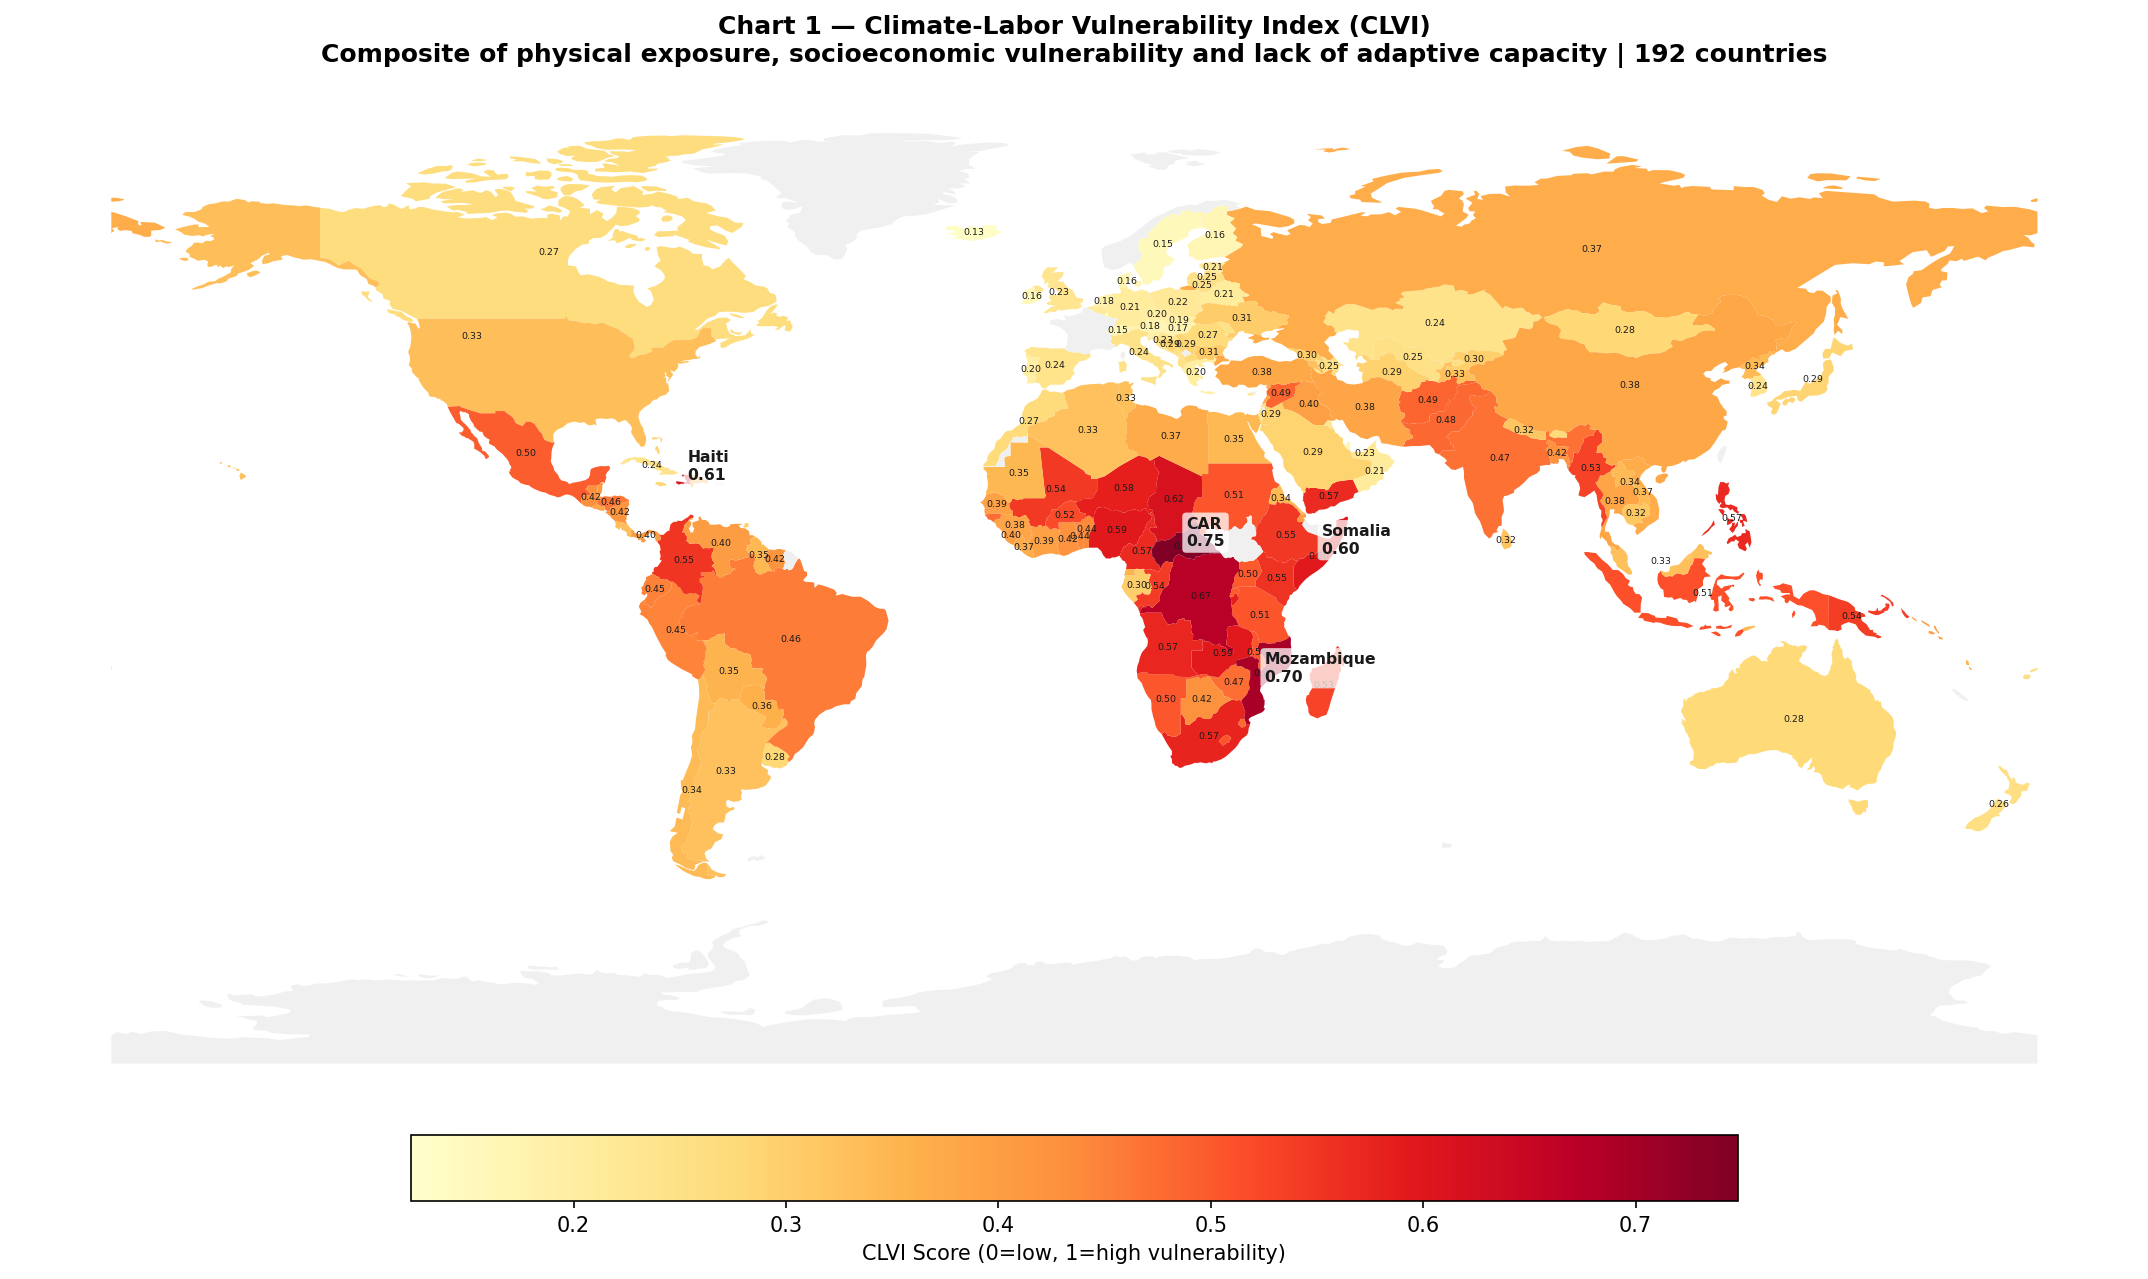

✓ Chart 1 saved


In [ ]:
#Cell 2 — Chart 1: CLVI Choropleth (add labels)
world_plot = world.merge(
    master[['iso3','CLVI','income_group','region_un']],
    left_on='ISO_A3', right_on='iso3', how='left'
)

fig, ax = plt.subplots(1, 1, figsize=(18, 9))

world_plot.plot(
    column='CLVI', cmap='YlOrRd', legend=True, ax=ax,
    missing_kwds={'color': '#f0f0f0', 'label': 'No data'},
    legend_kwds={
        'label': 'CLVI Score (0=low, 1=high vulnerability)',
        'shrink': 0.5, 'orientation': 'horizontal', 'pad': 0.02
    }
)

# Label every country with CLVI value if it has data
for _, row in world_plot.iterrows():
    if pd.notna(row['CLVI']):
        centroid = row.geometry.centroid
        # Only label if country is large enough to be readable
        area = row.geometry.area
        if area > 5:
            ax.annotate(
                f"{row['CLVI']:.2f}",
                xy=(centroid.x, centroid.y),
                ha='center', va='center',
                fontsize=4.5, color='#1a1a1a',
                fontweight='normal'
            )

# Annotate case study countries with name + value
case_coords = {
    'MOZ': (35.5,  -18.7, 'Mozambique'),
    'SOM': (46.2,    5.2, 'Somalia'),
    'HTI': (-72.3,  19.0, 'Haiti'),
    'CAF': (20.9,    6.6, 'CAR'),
}
for iso, (lon, lat, label) in case_coords.items():
    row = world_plot[world_plot['iso3'] == iso]
    val = row['CLVI'].values[0] if not row.empty and pd.notna(
        row['CLVI'].values[0]) else None
    text = f"{label}\n{val:.2f}" if val else label
    ax.annotate(
        text, xy=(lon, lat),
        fontsize=7.5, color='#1a1a1a', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  alpha=0.75, edgecolor='none')
    )

ax.set_title(
    'Chart 1 — Climate-Labor Vulnerability Index (CLVI)\n'
    'Composite of physical exposure, socioeconomic vulnerability '
    'and lack of adaptive capacity | 192 countries',
    fontsize=12, fontweight='bold', pad=12
)
ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/chart1_clvi_choropleth.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Chart 1 saved")

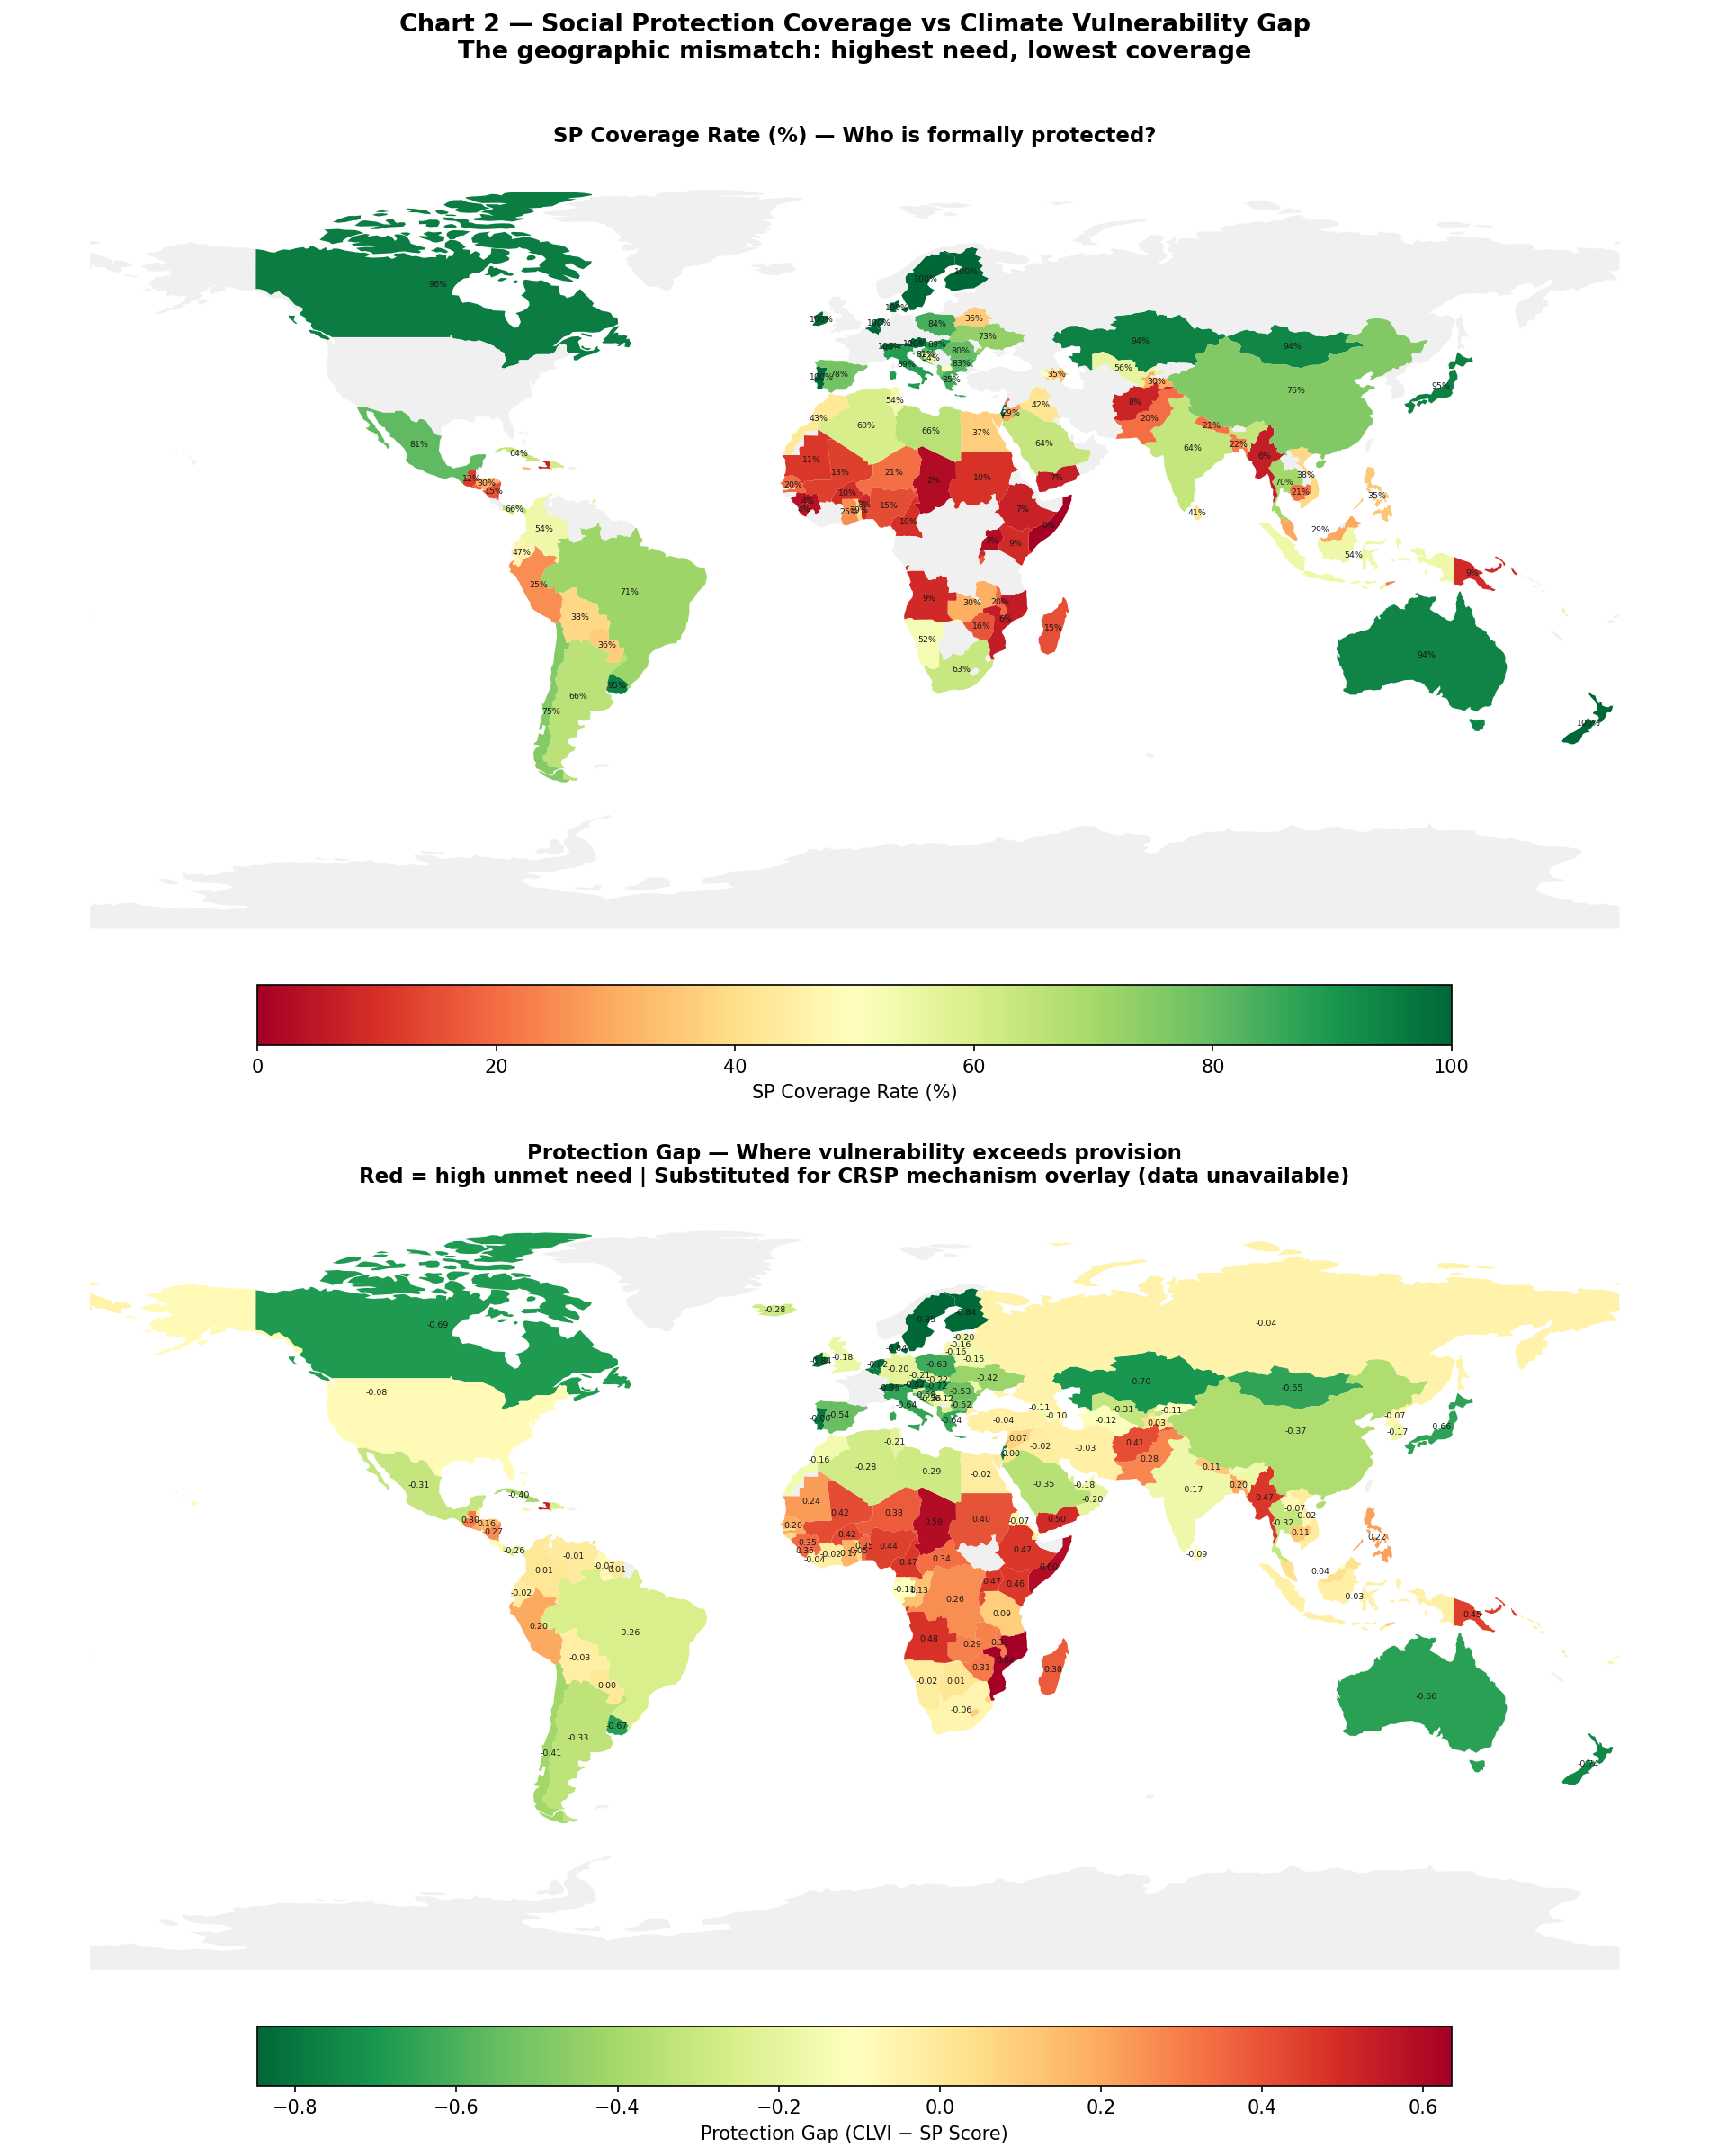

✓ Chart 2 saved


In [3]:
#Cell 3 — Chart 2: Protection Gap Map (add labels)

world_plot2 = world.merge(
    master[['iso3','protection_gap','sp_coverage_rate','CLVI']],
    left_on='ISO_A3', right_on='iso3', how='left'
)

fig, axes = plt.subplots(2, 1, figsize=(18, 16))

# Top map — SP coverage rate
world_plot2.plot(
    column='sp_coverage_rate', cmap='RdYlGn', legend=True,
    ax=axes[0],
    missing_kwds={'color': '#f0f0f0', 'label': 'No data'},
    legend_kwds={
        'label': 'SP Coverage Rate (%)',
        'shrink': 0.5, 'orientation': 'horizontal', 'pad': 0.02
    }
)

# Add SP coverage labels
for _, row in world_plot2.iterrows():
    if pd.notna(row['sp_coverage_rate']):
        centroid = row.geometry.centroid
        if row.geometry.area > 5:
            axes[0].annotate(
                f"{row['sp_coverage_rate']:.0f}%",
                xy=(centroid.x, centroid.y),
                ha='center', va='center',
                fontsize=4.5, color='#1a1a1a'
            )

axes[0].set_title(
    'SP Coverage Rate (%) — Who is formally protected?',
    fontsize=11, fontweight='bold'
)
axes[0].axis('off')

# Bottom map — protection gap
world_plot2.plot(
    column='protection_gap', cmap='RdYlGn_r', legend=True,
    ax=axes[1],
    missing_kwds={'color': '#f0f0f0', 'label': 'No data'},
    legend_kwds={
        'label': 'Protection Gap (CLVI − SP Score)',
        'shrink': 0.5, 'orientation': 'horizontal', 'pad': 0.02
    }
)

# Add protection gap labels
for _, row in world_plot2.iterrows():
    if pd.notna(row['protection_gap']):
        centroid = row.geometry.centroid
        if row.geometry.area > 5:
            axes[1].annotate(
                f"{row['protection_gap']:.2f}",
                xy=(centroid.x, centroid.y),
                ha='center', va='center',
                fontsize=4.5, color='#1a1a1a'
            )

axes[1].set_title(
    'Protection Gap — Where vulnerability exceeds provision\n'
    'Red = high unmet need | '
    'Substituted for CRSP mechanism overlay (data unavailable)',
    fontsize=11, fontweight='bold'
)
axes[1].axis('off')

fig.suptitle(
    'Chart 2 — Social Protection Coverage vs Climate Vulnerability Gap\n'
    'The geographic mismatch: highest need, lowest coverage',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('outputs/chart2_protection_gap_map.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Chart 2 saved")

In [6]:
#Cell 4 — Chart 3: Quadrant Scatter (Plotly, population-sized)
# Original spec: physical exposure vs SP coverage, sized by population
# Status: DONE with population sizing added

# Get population from WDI columns if available
pop_col = 'population' if 'population' in master.columns else None

plot_data = master[master['sp_coverage_rate'].notna()].copy()

if pop_col and plot_data[pop_col].notna().sum() > 50:
    plot_data['pop_size'] = np.sqrt(
        plot_data[pop_col].fillna(plot_data[pop_col].median()) / 1e6
    ) * 3
    size_col = 'pop_size'
    size_label = 'population'
else:
    plot_data['pop_size'] = 8
    size_col = None
    size_label = None

def quadrant(row):
    if row['CLVI'] >= 0.5 and row['sp_coverage_rate'] < 50:
        return 'Red Zone'
    elif row['CLVI'] >= 0.5 and row['sp_coverage_rate'] >= 50:
        return 'Tension Zone'
    elif row['CLVI'] < 0.5 and row['sp_coverage_rate'] < 50:
        return 'Gap Zone'
    else:
        return 'Safe Zone'

plot_data['quadrant'] = plot_data.apply(quadrant, axis=1)

color_map = {
    'Red Zone':     '#d73027',
    'Tension Zone': '#fc8d59',
    'Gap Zone':     '#fee090',
    'Safe Zone':    '#1a9850',
}

fig = px.scatter(
    plot_data,
    x='physical_exposure',
    y='sp_coverage_rate',
    color='quadrant',
    color_discrete_map=color_map,
    size='pop_size' if size_col else None,
    size_max=40,
    hover_name='country',
    hover_data={
        'physical_exposure':  ':.3f',
        'sp_coverage_rate':   ':.1f',
        'CLVI':               ':.3f',
        'gdp_per_capita':     ':,.0f',
        'gini':               ':.1f',
        'income_group':       True,
        'region_un':          True,
        'pop_size':           False,
        'quadrant':           False,
    },
    title=(
        'Chart 3 — Physical Climate Exposure vs Social Protection Coverage<br>'
        '<sup>Sized by population | '
        'Bottom-right quadrant = highest unmet need</sup>'
    ),
    labels={
        'physical_exposure':  'Physical Climate Exposure Score →',
        'sp_coverage_rate':   'SP Coverage Rate (%) →',
    }
)

fig.add_hline(y=50,  line_dash='dash', line_color='grey',
              opacity=0.4, line_width=1)
fig.add_vline(x=0.5, line_dash='dash', line_color='grey',
              opacity=0.4, line_width=1)

# Label case study countries
case_points = plot_data[
    plot_data['iso3'].isin(['MOZ','SOM','HTI'])
]
for _, row in case_points.iterrows():
    fig.add_annotation(
        x=row['physical_exposure'],
        y=row['sp_coverage_rate'],
        text=row['country'],
        showarrow=True, arrowhead=2,
        arrowsize=0.8, arrowwidth=1,
        font=dict(size=10, color='#333'),
        bgcolor='rgba(255,255,255,0.75)',
        ax=25, ay=-25
    )

fig.add_annotation(x=0.75, y=8,   text='RED ZONE',
                   showarrow=False,
                   font=dict(size=12, color='#d73027',
                             family='Arial Black'),
                   bgcolor='rgba(255,235,235,0.6)')
fig.add_annotation(x=0.12, y=92,  text='SAFE ZONE',
                   showarrow=False,
                   font=dict(size=12, color='#1a9850',
                             family='Arial Black'),
                   bgcolor='rgba(235,255,235,0.6)')

fig.update_traces(marker=dict(opacity=0.8,
                               line=dict(width=0.5, color='white')))
fig.update_layout(
    height=620,
    font=dict(family='Arial', size=11),
    plot_bgcolor='#FAFAFA',
    paper_bgcolor='white',
    legend=dict(title='Quadrant', orientation='h',
                yanchor='bottom', y=1.02,
                xanchor='right', x=1)
)

fig.write_html('outputs/chart3_quadrant_scatter.html')
fig.show()
print("✓ Chart 3 saved")
print(f"\nQuadrant counts:")
print(plot_data['quadrant'].value_counts())

✓ Chart 3 saved

Quadrant counts:
quadrant
Safe Zone       48
Gap Zone        40
Red Zone        21
Tension Zone     4
Name: count, dtype: int64


In [8]:
# Rebuild ilo_filtered from scratch
ilo_raw = pd.read_csv('data/raw/ilostat_social_protection.csv', encoding='utf-8')

# Rebuild ISO3 mapping
iso3_map = dict(zip(master['country'], master['iso3']))

ilo_name_patch = {
    'Bolivia (Plurinational State of)':                     'Bolivia',
    "Côte d'Ivoire":                                        "Cote d'Ivoire",
    'Congo, Democratic Republic of the':                    'Congo, Dem. Rep.',
    'Cabo Verde':                                           'Cape Verde',
    'Czechia':                                              'Czech Republic',
    'Micronesia (Federated States of)':                     'Micronesia, Fed. Sts.',
    'United Kingdom of Great Britain and Northern Ireland':  'United Kingdom',
    'Iran (Islamic Republic of)':                           'Iran, Islamic Rep.',
    'Republic of Korea':                                    'Korea, Rep.',
    'Republic of Moldova':                                  'Moldova',
    'Tanzania, United Republic of':                         'Tanzania',
    'United States of America':                             'United States',
    'Venezuela (Bolivarian Republic of)':                   'Venezuela',
    'Viet Nam':                                             'Vietnam',
    'Congo, Republic of the':                               'Congo, Rep.',
    "Lao People's Democratic Republic":                     'Lao PDR',
    'Russian Federation':                                   'Russia',
    'Türkiye':                                              'Turkey',
    'Kyrgyzstan':                                           'Kyrgyz Republic',
    'Slovakia':                                             'Slovak Republic',
    'Eswatini':                                             'Swaziland',
    'Gambia':                                               'Gambia, The',
    'Egypt':                                                'Egypt, Arab Rep.',
    'Yemen':                                                'Yemen, Rep.',
}

def ilo_to_iso3(name):
    if name in iso3_map:
        return iso3_map[name]
    patched = ilo_name_patch.get(name)
    if patched and patched in iso3_map:
        return iso3_map[patched]
    return np.nan

benefit_order = [
    'Contingency: Unemployed receiving unemployment benefits',
    'Contingency: Mothers with newborns receiving maternity benefits',
    'Contingency: Children/households receiving child/family cash benefits',
    'Contingency: Vulnerable persons covered by social assistance',
    'Contingency: Poor persons covered by social protection systems',
    'Contingency: Employed covered in the event of work injury',
    'Contingency: Persons with severe disabilities collecting disability social protection benefits',
    'Contingency: Persons above retirement age receiving a pension',
]

short_labels = {
    'Contingency: Unemployed receiving unemployment benefits':              'Unemployment',
    'Contingency: Mothers with newborns receiving maternity benefits':      'Maternity',
    'Contingency: Children/households receiving child/family cash benefits':'Child/Family',
    'Contingency: Vulnerable persons covered by social assistance':         'Vulnerable persons',
    'Contingency: Poor persons covered by social protection systems':       'Poor persons',
    'Contingency: Employed covered in the event of work injury':            'Work injury',
    'Contingency: Persons with severe disabilities collecting disability social protection benefits': 'Disability',
    'Contingency: Persons above retirement age receiving a pension':        'Pension',
}

ilo_merged = ilo_raw[ilo_raw['sex.label'] == 'Total'].copy()
ilo_merged['iso3'] = ilo_merged['ref_area.label'].apply(ilo_to_iso3)
ilo_merged = ilo_merged.merge(
    master[['iso3','income_group']], on='iso3', how='left'
)

ilo_filtered = ilo_merged[
    ilo_merged['classif1.label'].isin(benefit_order) &
    ilo_merged['income_group'].notna()
].copy()

print(f"✓ ilo_filtered rebuilt: {ilo_filtered.shape}")
print(f"  Income groups: {ilo_filtered['income_group'].unique()}")
print(f"  Benefit types: {ilo_filtered['classif1.label'].nunique()}")

✓ ilo_filtered rebuilt: (3513, 10)
  Income groups: ['Low income' 'Lower middle income' 'Upper middle income' 'High income']
  Benefit types: 7


Median coverage rate by income group and benefit type:
classif1.label       Unemployment  Child/Family  Vulnerable persons  Poor persons  Work injury  Disability  Pension
income_group                                                                                                       
Low income                    0.0           6.2                 5.2           5.1          6.8         1.3      9.1
Lower middle income           0.0          11.7                10.7          18.2         21.6         6.5     23.4
Upper middle income           0.0          26.9                29.4          40.1         47.4        45.4     85.9
High income                  43.6          91.5                75.8         100.0         85.5       100.0    100.0

Country count per cell:
classif1.label       Unemployment  Child/Family  Vulnerable persons  Poor persons  Work injury  Disability  Pension
income_group                                                                                                

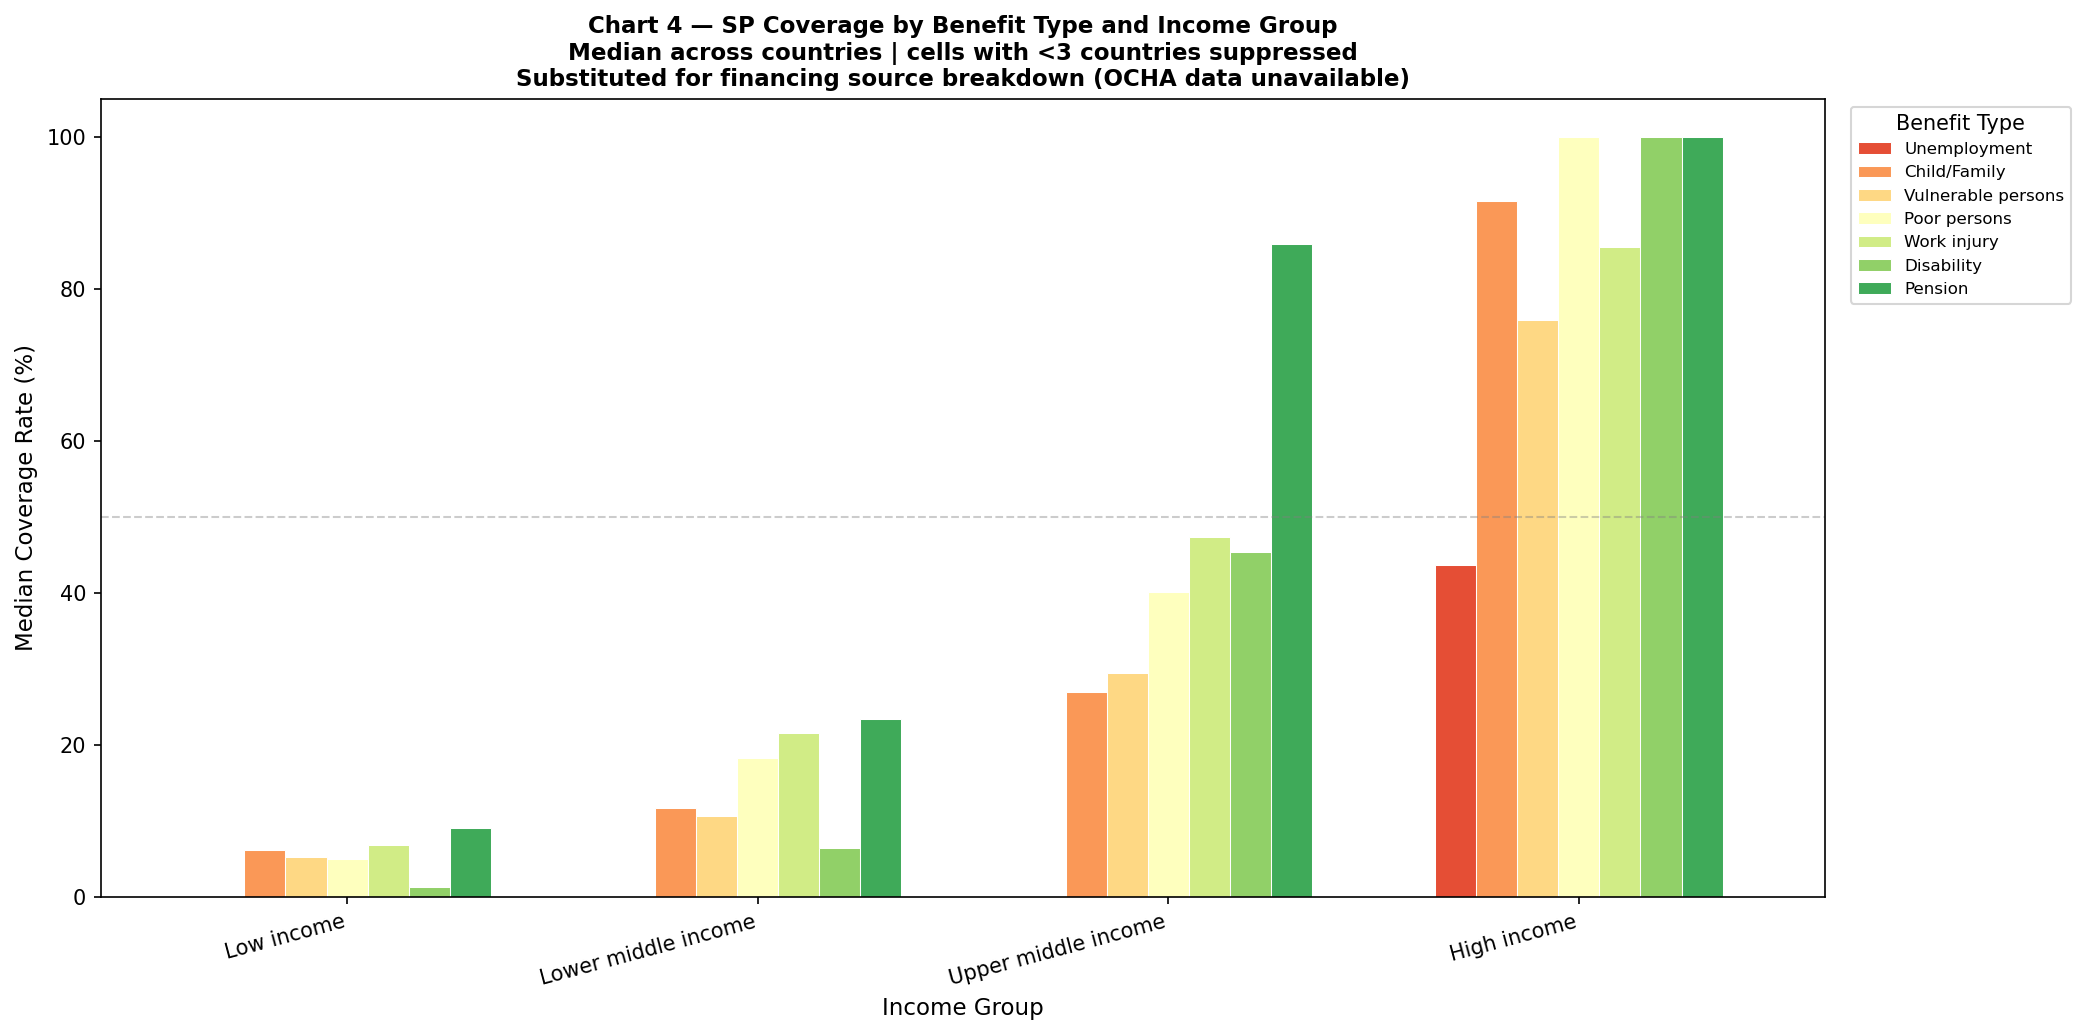

✓ Chart 4 saved

Median pivot used for chart:
classif1.label       Unemployment  Child/Family  Vulnerable persons  Poor persons  Work injury  Disability  Pension
income_group                                                                                                       
Low income                    0.0           6.2                 5.2           5.1          6.8         1.3      9.1
Lower middle income           0.0          11.7                10.7          18.2         21.6         6.5     23.4
Upper middle income           0.0          26.9                29.4          40.1         47.4        45.4     85.9
High income                  43.6          91.5                75.8         100.0         85.5       100.0    100.0


In [16]:
#Cell 5 — Chart 4: SP Coverage by Income Group & Region

# pivot with median + minimum count filter
ilo_latest_all = (ilo_filtered
                  .sort_values('time', ascending=False)
                  .groupby(['income_group','classif1.label','ref_area.label'])
                  .first()
                  .reset_index())

# Count countries per cell
count_pivot = ilo_latest_all.pivot_table(
    index='income_group',
    columns='classif1.label',
    values='obs_value',
    aggfunc='count'
).reindex(['Low income','Lower middle income',
           'Upper middle income','High income'])
count_pivot = count_pivot.rename(columns=short_labels)

# Median pivot
median_pivot = ilo_latest_all.pivot_table(
    index='income_group',
    columns='classif1.label',
    values='obs_value',
    aggfunc='median'
).reindex(['Low income','Lower middle income',
           'Upper middle income','High income'])
median_pivot = median_pivot.rename(columns=short_labels)

ordered_cols = [short_labels[b] for b in benefit_order
                if short_labels[b] in median_pivot.columns]
median_pivot = median_pivot[ordered_cols]
count_pivot  = count_pivot[[c for c in ordered_cols
                            if c in count_pivot.columns]]

# Mask cells with fewer than 3 countries
mask = count_pivot < 3
median_pivot[mask] = np.nan

print("Median coverage rate by income group and benefit type:")
print(median_pivot.round(1).to_string())
print("\nCountry count per cell:")
print(count_pivot.to_string())

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

colors_bar = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(ordered_cols)))
median_pivot.plot(kind='bar', ax=ax, color=colors_bar,
                  width=0.7, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Income Group', fontsize=11)
ax.set_ylabel('Median Coverage Rate (%)', fontsize=11)
ax.set_title(
    'Chart 4 — SP Coverage by Benefit Type and Income Group\n'
    'Median across countries | cells with <3 countries suppressed\n'
    'Substituted for financing source breakdown (OCHA data unavailable)',
    fontsize=11, fontweight='bold'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Benefit Type', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=8)
ax.axhline(50, color='grey', linestyle='--', alpha=0.4, linewidth=1)
ax.set_ylim(0, 105)


plt.tight_layout()
plt.savefig('outputs/chart4_coverage_by_income_benefit.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Chart 4 saved")
print("\nMedian pivot used for chart:")
print(median_pivot.round(1).to_string())

✓ ilo_filtered: (3513, 10)
Median coverage rate by income group and benefit type:
classif1.label       Unemployment  Child/Family  Vulnerable persons  Poor persons  Work injury  Disability  Pension
income_group                                                                                                       
Low income                    0.0           6.2                 5.2           5.1          6.8         1.3      9.1
Lower middle income           0.0          11.7                10.7          18.2         21.6         6.5     23.4
Upper middle income           0.0          26.9                29.4          40.1         47.4        45.4     85.9
High income                  43.6          91.5                75.8         100.0         85.5       100.0    100.0


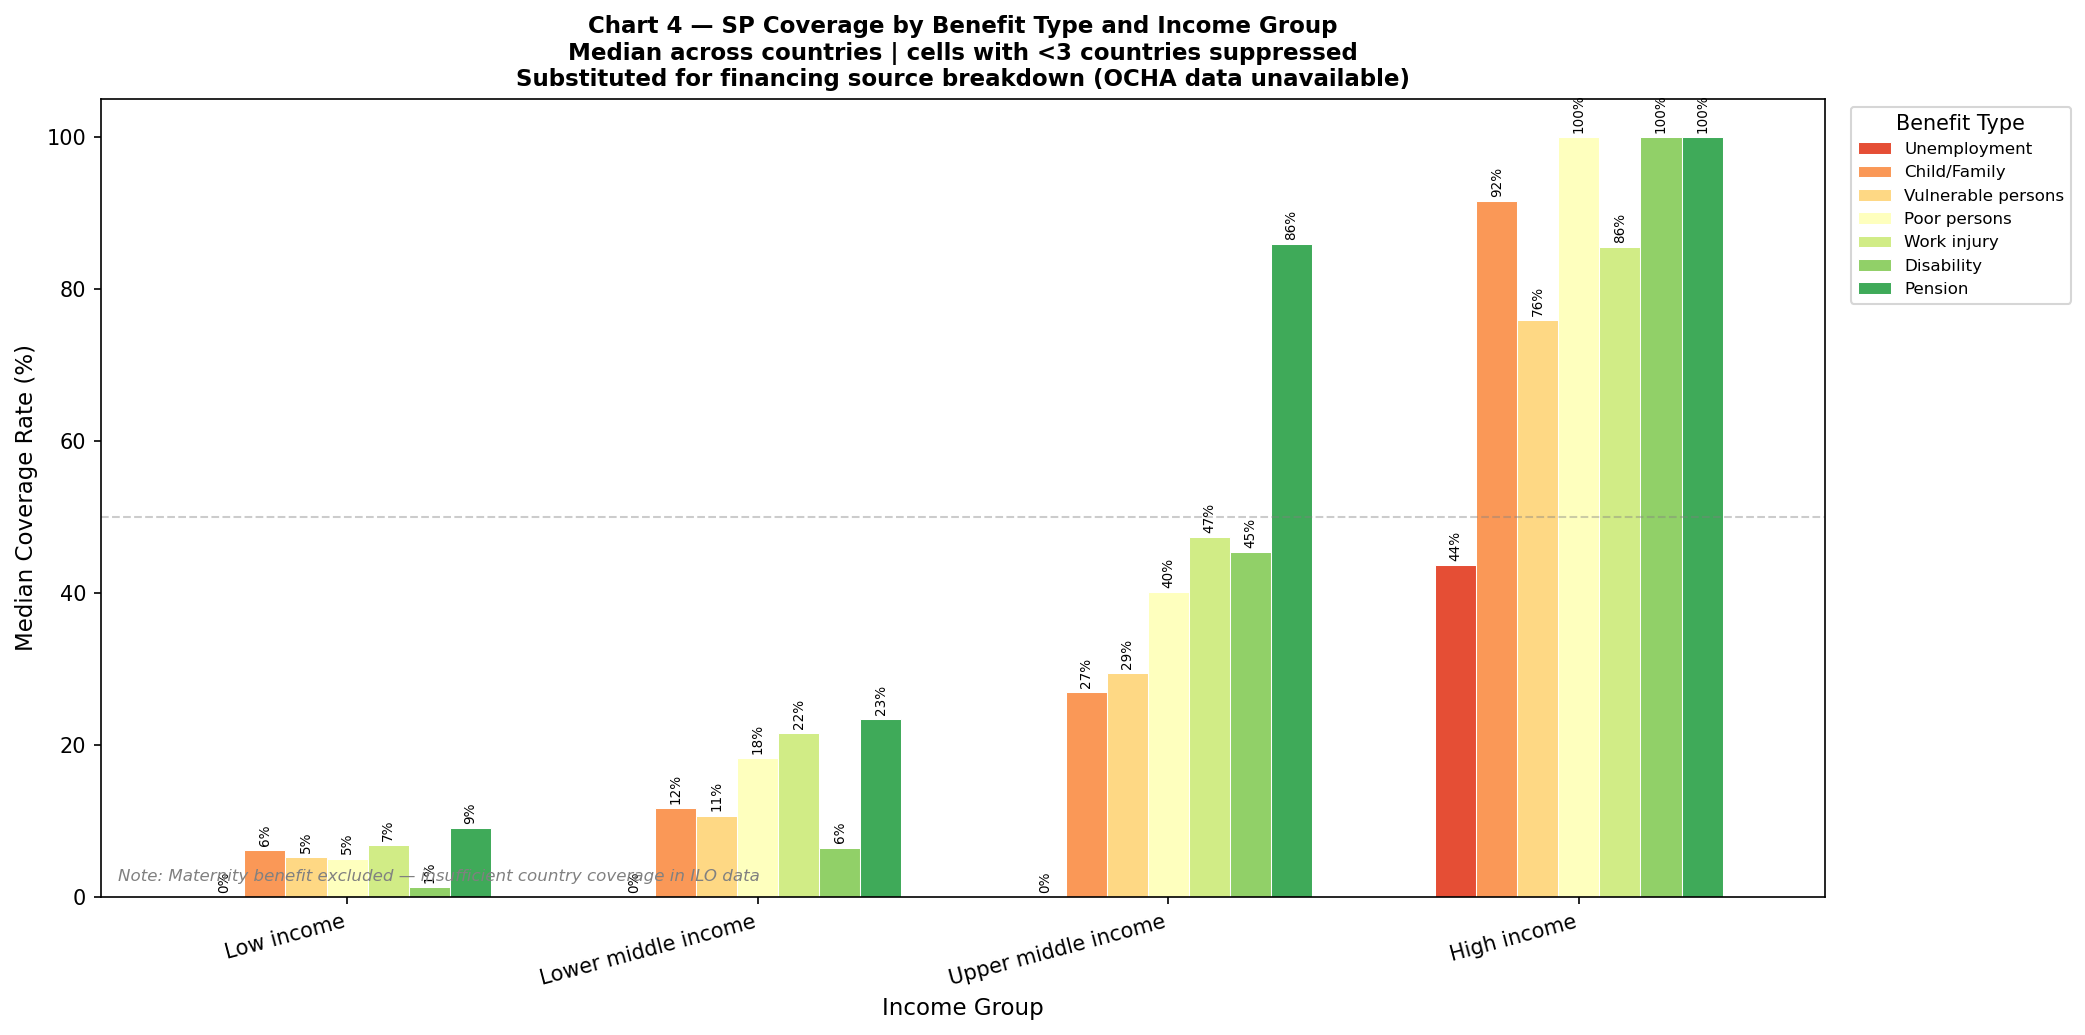

✓ Chart 4 saved


In [ ]:
# ── CELL 5 — Chart 4: SP Coverage by Income Group & Benefit Type ──────────────

# Step 1: Rebuild dependencies
ilo_raw = pd.read_csv('data/raw/ilostat_social_protection.csv', encoding='utf-8')

iso3_map = dict(zip(master['country'], master['iso3']))

ilo_name_patch = {
    'Bolivia (Plurinational State of)':                     'Bolivia',
    "Côte d'Ivoire":                                        "Cote d'Ivoire",
    'Congo, Democratic Republic of the':                    'Congo, Dem. Rep.',
    'Cabo Verde':                                           'Cape Verde',
    'Czechia':                                              'Czech Republic',
    'Micronesia (Federated States of)':                     'Micronesia, Fed. Sts.',
    'United Kingdom of Great Britain and Northern Ireland':  'United Kingdom',
    'Iran (Islamic Republic of)':                           'Iran, Islamic Rep.',
    'Republic of Korea':                                    'Korea, Rep.',
    'Republic of Moldova':                                  'Moldova',
    'Tanzania, United Republic of':                         'Tanzania',
    'United States of America':                             'United States',
    'Venezuela (Bolivarian Republic of)':                   'Venezuela',
    'Viet Nam':                                             'Vietnam',
    'Congo, Republic of the':                               'Congo, Rep.',
    "Lao People's Democratic Republic":                     'Lao PDR',
    'Russian Federation':                                   'Russia',
    'Türkiye':                                              'Turkey',
    'Kyrgyzstan':                                           'Kyrgyz Republic',
    'Slovakia':                                             'Slovak Republic',
    'Eswatini':                                             'Swaziland',
    'Gambia':                                               'Gambia, The',
    'Egypt':                                                'Egypt, Arab Rep.',
    'Yemen':                                                'Yemen, Rep.',
}

def ilo_to_iso3(name):
    if name in iso3_map:
        return iso3_map[name]
    patched = ilo_name_patch.get(name)
    if patched and patched in iso3_map:
        return iso3_map[patched]
    return np.nan

benefit_order = [
    'Contingency: Unemployed receiving unemployment benefits',
    'Contingency: Mothers with newborns receiving maternity benefits',
    'Contingency: Children/households receiving child/family cash benefits',
    'Contingency: Vulnerable persons covered by social assistance',
    'Contingency: Poor persons covered by social protection systems',
    'Contingency: Employed covered in the event of work injury',
    'Contingency: Persons with severe disabilities collecting disability social protection benefits',
    'Contingency: Persons above retirement age receiving a pension',
]

short_labels = {
    'Contingency: Unemployed receiving unemployment benefits':               'Unemployment',
    'Contingency: Mothers with newborns receiving maternity benefits':       'Maternity',
    'Contingency: Children/households receiving child/family cash benefits': 'Child/Family',
    'Contingency: Vulnerable persons covered by social assistance':          'Vulnerable persons',
    'Contingency: Poor persons covered by social protection systems':        'Poor persons',
    'Contingency: Employed covered in the event of work injury':             'Work injury',
    'Contingency: Persons with severe disabilities collecting disability social protection benefits': 'Disability',
    'Contingency: Persons above retirement age receiving a pension':         'Pension',
}

ilo_merged = ilo_raw[ilo_raw['sex.label'] == 'Total'].copy()
ilo_merged['iso3'] = ilo_merged['ref_area.label'].apply(ilo_to_iso3)
ilo_merged = ilo_merged.merge(
    master[['iso3','income_group']], on='iso3', how='left'
)

ilo_filtered = ilo_merged[
    ilo_merged['classif1.label'].isin(benefit_order) &
    ilo_merged['income_group'].notna()
].copy()

print(f"✓ ilo_filtered: {ilo_filtered.shape}")

# Step 2: Build pivot
ilo_latest_all = (ilo_filtered
                  .sort_values('time', ascending=False)
                  .groupby(['income_group','classif1.label','ref_area.label'])
                  .first()
                  .reset_index())

count_pivot = ilo_latest_all.pivot_table(
    index='income_group',
    columns='classif1.label',
    values='obs_value',
    aggfunc='count'
).reindex(['Low income','Lower middle income',
           'Upper middle income','High income'])
count_pivot = count_pivot.rename(columns=short_labels)

median_pivot = ilo_latest_all.pivot_table(
    index='income_group',
    columns='classif1.label',
    values='obs_value',
    aggfunc='median'
).reindex(['Low income','Lower middle income',
           'Upper middle income','High income'])
median_pivot = median_pivot.rename(columns=short_labels)

ordered_cols = [short_labels[b] for b in benefit_order
                if short_labels[b] in median_pivot.columns]
median_pivot = median_pivot[ordered_cols]
count_pivot  = count_pivot[[c for c in ordered_cols
                            if c in count_pivot.columns]]

mask = count_pivot < 3
median_pivot[mask] = np.nan

print("Median coverage rate by income group and benefit type:")
print(median_pivot.round(1).to_string())

# Step 3: Plot
fig, ax = plt.subplots(figsize=(14, 7))

colors_bar = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(ordered_cols)))
median_pivot.plot(kind='bar', ax=ax, color=colors_bar,
                  width=0.7, edgecolor='white', linewidth=0.5)

# Add value labels on each bar
for container in ax.containers:
    labels = [f'{v:.0f}%' if not np.isnan(v) else ''
              for v in container.datavalues]
    ax.bar_label(container, labels=labels,
                 label_type='edge', fontsize=6.5,
                 padding=2, rotation=90)

ax.set_xlabel('Income Group', fontsize=11)
ax.set_ylabel('Median Coverage Rate (%)', fontsize=11)
ax.set_title(
    'Chart 4 — SP Coverage by Benefit Type and Income Group\n'
    'Median across countries | cells with <3 countries suppressed\n'
    'Substituted for financing source breakdown (OCHA data unavailable)',
    fontsize=11, fontweight='bold'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Benefit Type', bbox_to_anchor=(1.01, 1),
          loc='upper left', fontsize=8)
ax.axhline(50, color='grey', linestyle='--', alpha=0.4, linewidth=1)
ax.set_ylim(0, 105)
ax.text(0.01, 0.02,
        'Note: Maternity benefit excluded — insufficient country coverage in ILO data',
        transform=ax.transAxes, fontsize=8, color='grey', style='italic')

plt.tight_layout()
plt.savefig('outputs/chart4_coverage_by_income_benefit.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Chart 4 saved")

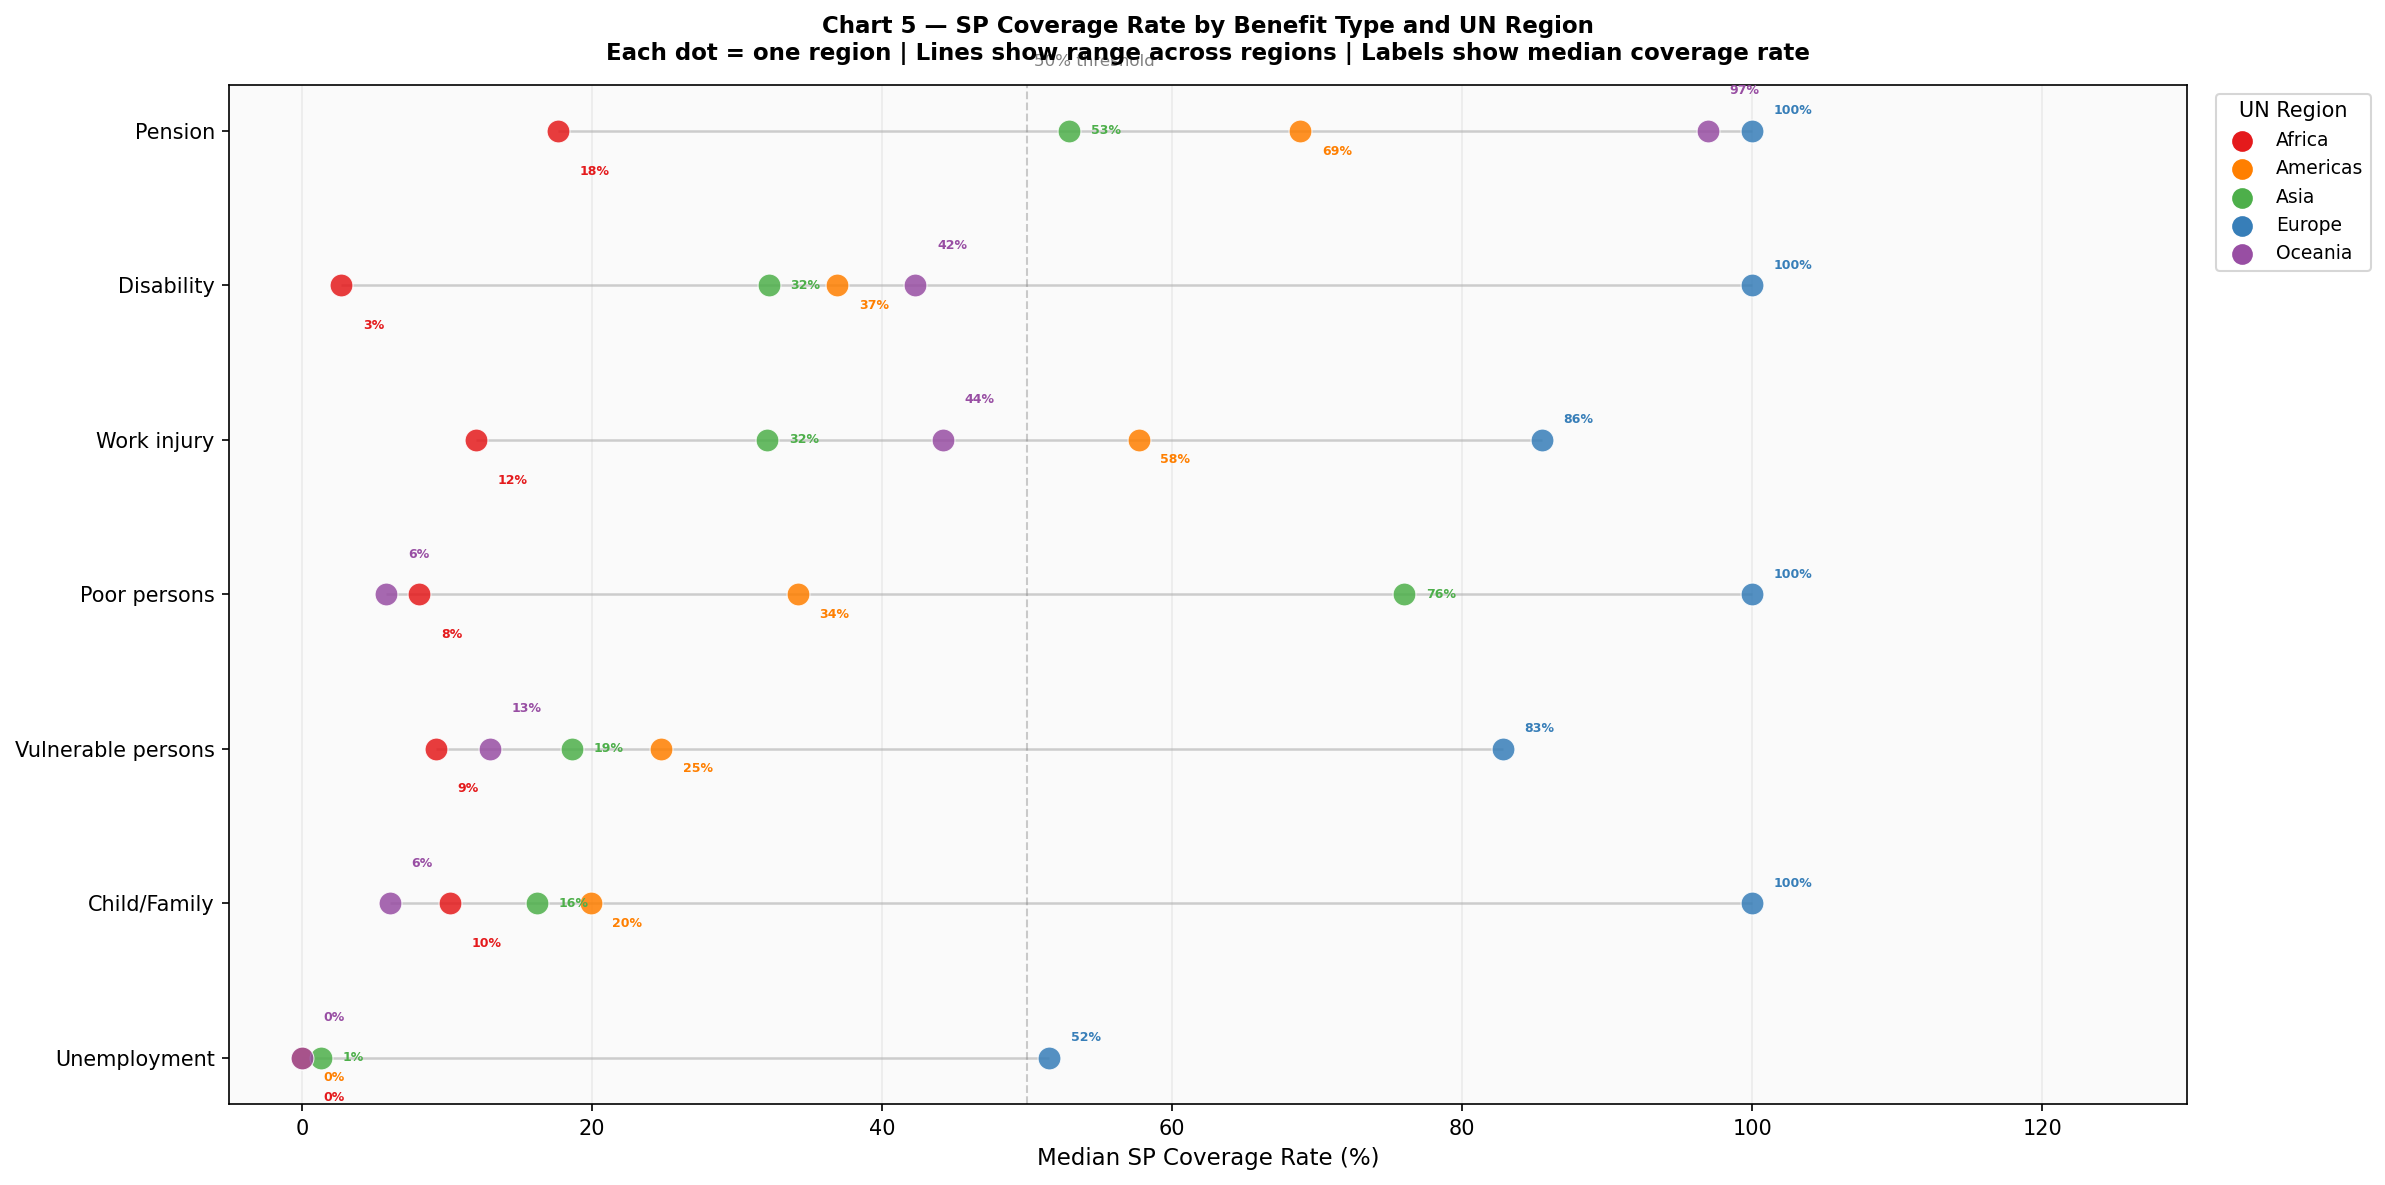

✓ Chart 5 saved with labels


In [13]:
#Cell 6 — Chart 5 Dot Plot with Labels

# Chart 5 — Dot plot with labels
ilo_merged2 = ilo_raw[ilo_raw['sex.label'] == 'Total'].copy()
ilo_merged2['iso3'] = ilo_merged2['ref_area.label'].apply(ilo_to_iso3)
ilo_merged2 = ilo_merged2.merge(
    master[['iso3','region_un']], on='iso3', how='left'
)

ilo_region = ilo_merged2[
    ilo_merged2['classif1.label'].isin(benefit_order) &
    ilo_merged2['region_un'].notna()
].copy()

ilo_region_latest = (ilo_region
                     .sort_values('time', ascending=False)
                     .groupby(['region_un','classif1.label',
                               'ref_area.label'])
                     .first()
                     .reset_index())

pivot2 = ilo_region_latest.pivot_table(
    index='region_un',
    columns='classif1.label',
    values='obs_value',
    aggfunc='median'
).rename(columns=short_labels)

pivot2 = pivot2[[c for c in ordered_cols if c in pivot2.columns]]

pivot_long = pivot2.reset_index().melt(
    id_vars='region_un',
    var_name='benefit_type',
    value_name='coverage'
)

region_colors = {
    'Africa':   '#e41a1c',
    'Americas': '#ff7f00',
    'Asia':     '#4daf4a',
    'Europe':   '#377eb8',
    'Oceania':  '#984ea3',
}

fig, ax = plt.subplots(figsize=(16, 8))

benefit_types = pivot2.columns.tolist()
y_positions   = np.arange(len(benefit_types))

# Track label positions per row to avoid overlap
for region, color in region_colors.items():
    region_data = pivot_long[pivot_long['region_un'] == region]
    for bt, ypos in zip(benefit_types, y_positions):
        val = region_data[region_data['benefit_type'] == bt]['coverage']
        if not val.empty and pd.notna(val.values[0]):
            v = val.values[0]
            ax.scatter(v, ypos,
                       color=color, s=120, alpha=0.85,
                       zorder=3, edgecolors='white', linewidth=0.5)
            # Label above dot, slightly offset per region to reduce overlap
            region_list = list(region_colors.keys())
            r_idx = region_list.index(region)
            y_offset = (r_idx - 2) * 0.13
            ax.annotate(
                f'{v:.0f}%',
                xy=(v, ypos),
                xytext=(v + 1.5, ypos + y_offset),
                fontsize=6, color=color,
                va='center', ha='left',
                fontweight='bold'
            )

# Connecting lines showing range per benefit type
for ypos, bt in enumerate(benefit_types):
    bt_data = pivot_long[pivot_long['benefit_type'] == bt]['coverage'].dropna()
    if not bt_data.empty:
        ax.hlines(ypos, bt_data.min(), bt_data.max(),
                  color='#cccccc', linewidth=1.2, zorder=1)

ax.set_yticks(y_positions)
ax.set_yticklabels(benefit_types, fontsize=10)
ax.set_xlabel('Median SP Coverage Rate (%)', fontsize=11)
ax.set_xlim(-5, 130)  # extended right margin for labels
ax.axvline(50, color='grey', linestyle='--', alpha=0.4, linewidth=1)
ax.text(50.5, len(benefit_types) - 0.5, '50% threshold',
        color='grey', fontsize=8, va='top')

ax.set_title(
    'Chart 5 — SP Coverage Rate by Benefit Type and UN Region\n'
    'Each dot = one region | Lines show range across regions | '
    'Labels show median coverage rate',
    fontsize=11, fontweight='bold', pad=12
)

legend_handles = [
    plt.scatter([], [], color=color, s=80, label=region)
    for region, color in region_colors.items()
]
ax.legend(handles=legend_handles, title='UN Region',
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

ax.grid(axis='x', alpha=0.2)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('outputs/chart5_coverage_dotplot.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Chart 5 saved with labels")

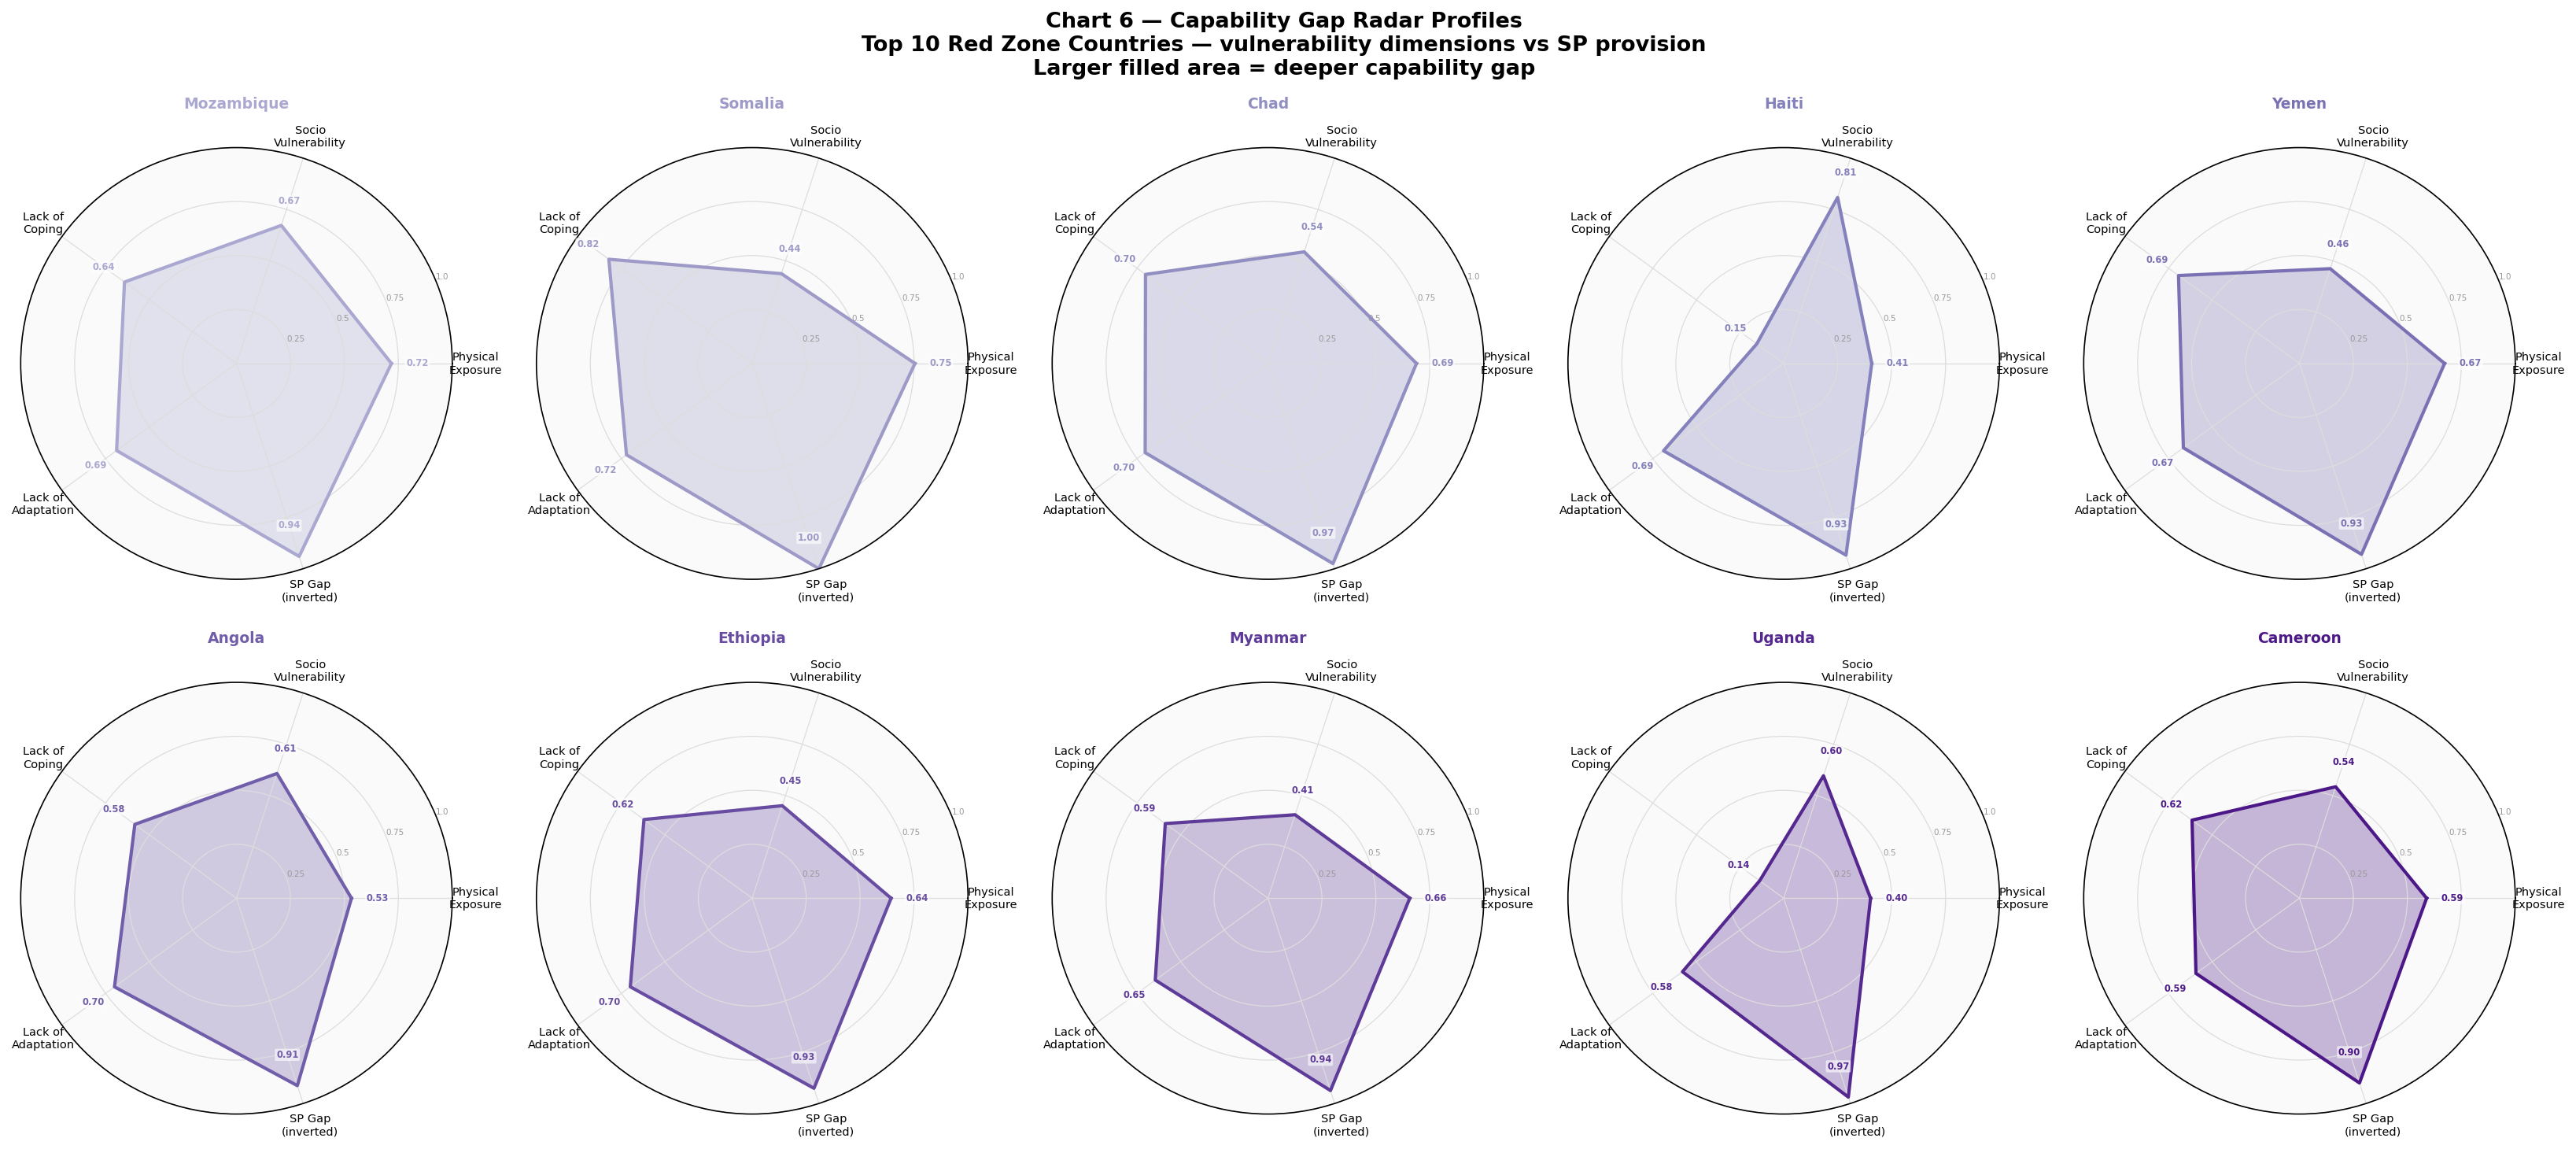

✓ Chart 6 saved — indigo/purple palette with labels


In [14]:
#cell 7 — Chart 6: Radar Profiles of Top Red Zone Countries
top10 = (master[master['sp_coverage_rate'].notna()]
         .nlargest(10, 'protection_gap')
         [['country','iso3','CLVI','physical_exposure',
           'socio_vulnerability','sp_score',
           'lack_coping','lack_adaptation']]
         .reset_index(drop=True))

top10['lack_coping_n']     = top10['lack_coping']    / 100
top10['lack_adaptation_n'] = top10['lack_adaptation'] / 100
top10['sp_inverted']       = 1 - top10['sp_score']

dim_cols   = ['physical_exposure','socio_vulnerability',
              'lack_coping_n','lack_adaptation_n','sp_inverted']
dimensions = ['Physical\nExposure','Socio\nVulnerability',
              'Lack of\nCoping','Lack of\nAdaptation','SP Gap\n(inverted)']

N      = len(dimensions)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 5, figsize=(22, 10),
                          subplot_kw=dict(polar=True))
fig.suptitle(
    'Chart 6 — Capability Gap Radar Profiles\n'
    'Top 10 Red Zone Countries — vulnerability dimensions vs SP provision\n'
    'Larger filled area = deeper capability gap',
    fontsize=13, fontweight='bold'
)

purple_cmap = plt.cm.Purples(np.linspace(0.45, 0.92, 10))

for idx, (ax, (_, row)) in enumerate(
        zip(axes.flatten(), top10.iterrows())):

    values  = [row[c] for c in dim_cols]
    values += values[:1]

    color = purple_cmap[idx]

    ax.plot(angles, values,
            color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values,
            color=color, alpha=0.30)

    # Add value label at each axis point
    for angle, value, dim in zip(angles[:-1], values[:-1], dimensions):
        # Offset label outward from the data point
        label_r = value + 0.12
        if label_r > 1.0:
            label_r = value - 0.15  # flip inward if too close to edge

        ax.annotate(
            f'{value:.2f}',
            xy=(angle, value),
            xytext=(angle, label_r),
            ha='center', va='center',
            fontsize=5.5,
            color=color,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.15',
                      facecolor='white',
                      alpha=0.6,
                      edgecolor='none')
        )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dimensions, size=7)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.5','0.75','1.0'],
                        size=5, color='#999999')

    short = (row['country'] if len(row['country']) <= 20
             else row['country'][:18] + '…')
    ax.set_title(short, size=9, fontweight='bold',
                  pad=10, color=color)

    ax.grid(color='#dddddd', linewidth=0.6)
    ax.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('outputs/chart6_radar_redzone.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("✓ Chart 6 saved — indigo/purple palette with labels")

In [15]:
import os

charts = [
    ('outputs/chart1_clvi_choropleth.png',           'Chart 1 — CLVI Choropleth'),
    ('outputs/chart2_protection_gap_map.png',         'Chart 2 — Protection Gap Map'),
    ('outputs/chart3_quadrant_scatter.html',          'Chart 3 — Quadrant Scatter (interactive)'),
    ('outputs/chart4_coverage_by_income_benefit.png', 'Chart 4 — Coverage by Income & Benefit'),
    ('outputs/chart5_coverage_dotplot.png',           'Chart 5 — Coverage Dot Plot by Region'),
    ('outputs/chart6_radar_redzone.png',              'Chart 6 — Radar: Top 10 Red Zone'),
]

print("=== VISUALISATION SUITE — OUTPUT STATUS ===\n")
for path, label in charts:
    exists = os.path.exists(path)
    size   = f"{os.path.getsize(path)/1024:.0f}KB" if exists else "—"
    status = "✓" if exists else "✗ MISSING"
    print(f"  {status}  {label}")
    print(f"       {path} ({size})\n")

=== VISUALISATION SUITE — OUTPUT STATUS ===

  ✓  Chart 1 — CLVI Choropleth
       outputs/chart1_clvi_choropleth.png (391KB)

  ✓  Chart 2 — Protection Gap Map
       outputs/chart2_protection_gap_map.png (712KB)

  ✓  Chart 3 — Quadrant Scatter (interactive)
       outputs/chart3_quadrant_scatter.html (4681KB)

  ✓  Chart 4 — Coverage by Income & Benefit
       outputs/chart4_coverage_by_income_benefit.png (204KB)

  ✓  Chart 5 — Coverage Dot Plot by Region
       outputs/chart5_coverage_dotplot.png (196KB)

  ✓  Chart 6 — Radar: Top 10 Red Zone
       outputs/chart6_radar_redzone.png (786KB)

